# Conhecendo a base de dados

## Importando os dados


In [54]:
import pandas as pd

In [55]:
import numpy as np

In [56]:
import pandas as pd
df = pd.read_csv('datasets/aluguel.csv')

In [57]:
print("Linhas, colunas:", df.shape)

Linhas, colunas: (32960, 1)


In [58]:
print("\nColunas:\n", df.columns.tolist())


Colunas:
 ['Tipo;Bairro;Quartos;Vagas;Suites;Area;Valor;Condominio;IPTU']


In [59]:
df.dtypes.to_frame("dtype")

,dtype
Tipo;Bairro;Quartos;Vagas;Suites;Area;Valor;Condominio;IPTU,object


In [60]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 1 columns):
 #   Column                                                       Non-Null Count  Dtype 
---  ------                                                       --------------  ----- 
 0   Tipo;Bairro;Quartos;Vagas;Suites;Area;Valor;Condominio;IPTU  32960 non-null  object
dtypes: object(1)
memory usage: 3.4 MB


In [61]:
mem_mb = df.memory_usage(deep=True).sum() / 1_048_576

In [62]:
print(f"\nMemória total ~ {mem_mb:.2f} MB")


Memória total ~ 3.44 MB


In [63]:
url = "datasets/aluguel.csv"

In [64]:
dados = pd.read_csv(url, sep=";")

## Características gerais da base de dados

In [65]:
df.head()

,Tipo;Bairro;Quartos;Vagas;Suites;Area;Valor;Condominio;IPTU
0,Quitinete;Copacabana;1;0;0;40;1700;500;60
1,Casa;Jardim Botânico;2;0;1;100;7000;;
2,Conjunto Comercial/Sala;Barra da Tijuca;0;4;0;...
3,Apartamento;Centro;1;0;0;15;800;390;20
4,Apartamento;Higienópolis;1;0;0;48;800;230;


In [66]:
print("A base possui", df.shape[0], "linhas e", df.shape[1], "colunas.\n")

A base possui 32960 linhas e 1 colunas.



In [67]:
print("Colunas disponíveis:")

Colunas disponíveis:


In [68]:
print(df.columns.tolist(), "\n")

['Tipo;Bairro;Quartos;Vagas;Suites;Area;Valor;Condominio;IPTU'] 



In [69]:
print("Tipos de dados:")

Tipos de dados:


In [70]:
print(df.dtypes, "\n")

Tipo;Bairro;Quartos;Vagas;Suites;Area;Valor;Condominio;IPTU    object
dtype: object 



In [71]:
print("Informações da base:")

Informações da base:


In [72]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 1 columns):
 #   Column                                                       Non-Null Count  Dtype 
---  ------                                                       --------------  ----- 
 0   Tipo;Bairro;Quartos;Vagas;Suites;Area;Valor;Condominio;IPTU  32960 non-null  object
dtypes: object(1)
memory usage: 257.6+ KB
None


# Análise exploratória de dados

## Qual o valor médio de aluguel por tipo de imóvel?

In [73]:
print(df.columns.tolist())

['Tipo;Bairro;Quartos;Vagas;Suites;Area;Valor;Condominio;IPTU']


In [74]:
df = df.rename(columns=lambda c: c.strip().lower())

In [75]:
print(df.columns.tolist())

['tipo;bairro;quartos;vagas;suites;area;valor;condominio;iptu']


In [82]:
import pandas as pd

In [85]:
%pip install matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
import matplotlib.pyplot as plt

In [87]:
df = pd.read_csv("datasets/aluguel.csv", sep=";", encoding="utf-8")

In [88]:
df = df.rename(columns=lambda c: c.strip().lower())
print(df.columns.tolist())  # deve mostrar: ['tipo','bairro','quartos','vagas','suites','area','valor','condominio','iptu']

['tipo', 'bairro', 'quartos', 'vagas', 'suites', 'area', 'valor', 'condominio', 'iptu']


In [89]:
# 3) Garantir tipos numéricos (se já estiverem numéricos, isso só confirma)
for c in ['quartos','vagas','suites','area','valor','condominio','iptu']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

In [90]:
# 4) Valor médio de aluguel por tipo de imóvel
media_tipo = (
    df.groupby('tipo', dropna=False)['valor']
      .mean()
      .sort_values(ascending=False)
)

print(media_tipo)

tipo
Prédio Inteiro                 498637.239203
Indústria                      120000.000000
Galpão/Depósito/Armazém         53407.062600
Terreno Padrão                  32567.714286
Hotel                           25000.000000
Loteamento/Condomínio           22000.000000
Conjunto Comercial/Sala         14715.045521
Casa Comercial                  14478.264151
Loja/Salão                      13769.646770
Sítio                           12499.000000
Casa de Condomínio              11952.061245
Loja Shopping/ Ct Comercial      8126.178862
Casa                             6793.454922
Chácara                          4900.000000
Apartamento                      4744.614648
Flat                             4546.189076
Loft                             2557.882353
Studio                           2400.000000
Box/Garagem                      1899.756098
Casa de Vila                     1574.369478
Pousada/Chalé                    1480.000000
Quitinete                        1246.840909
Name:

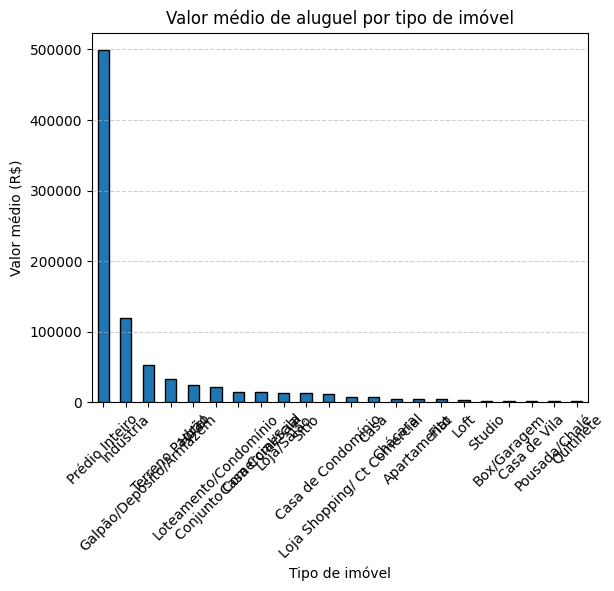

In [91]:
# 5) Gráfico (opcional)
media_tipo.plot(kind='bar', edgecolor='black')
plt.title('Valor médio de aluguel por tipo de imóvel')
plt.ylabel('Valor médio (R$)')
plt.xlabel('Tipo de imóvel')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Removendo os imóveis comerciais

In [92]:
comerciais = [
    'conjunto comercial/sala', 'loja/salão', 'ponto comercial',
    'galpão/depósito/armazém', 'prédio inteiro', 'box/garagem',
    'hotel', 'kiosk', 'andar', 'terreno comercial'
]

# normaliza a coluna 'tipo' para comparar com segurança
tipos_norm = df['tipo'].astype(str).str.strip().str.lower()

df_resid = df[~tipos_norm.isin([t.lower() for t in comerciais])].copy()
print("Tamanho original:", len(df), " | Após remover comerciais:", len(df_resid))


Tamanho original: 32960  | Após remover comerciais: 23711


In [93]:
# garante que 'valor' é numérico
df_resid['valor'] = pd.to_numeric(df_resid['valor'], errors='coerce')

media_tipo_resid = (
    df_resid.groupby('tipo', dropna=False)['valor']
            .mean()
            .sort_values(ascending=False)
)

print(media_tipo_resid)


tipo
Indústria                      120000.000000
Terreno Padrão                  32567.714286
Loteamento/Condomínio           22000.000000
Casa Comercial                  14478.264151
Sítio                           12499.000000
Casa de Condomínio              11952.061245
Loja Shopping/ Ct Comercial      8126.178862
Casa                             6793.454922
Chácara                          4900.000000
Apartamento                      4744.614648
Flat                             4546.189076
Loft                             2557.882353
Studio                           2400.000000
Casa de Vila                     1574.369478
Pousada/Chalé                    1480.000000
Quitinete                        1246.840909
Name: valor, dtype: float64


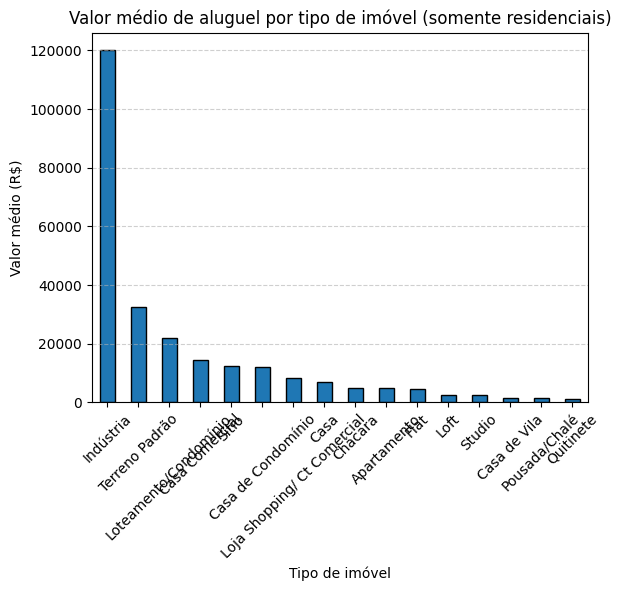

In [94]:
import matplotlib.pyplot as plt

media_tipo_resid.plot(kind='bar', edgecolor='black')
plt.title('Valor médio de aluguel por tipo de imóvel (somente residenciais)')
plt.ylabel('Valor médio (R$)')
plt.xlabel('Tipo de imóvel')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [97]:
comerciais = [
    'conjunto comercial/sala', 'loja/salão', 'ponto comercial',
    'galpão/depósito/armazém', 'prédio inteiro', 'box/garagem',
    'hotel', 'kiosk', 'andar', 'terreno comercial'
]


In [98]:
# Normalizar a coluna tipo pra facilitar
tipos_norm = df['tipo'].astype(str).str.strip().str.lower()

df_comerc = df[tipos_norm.isin([t.lower() for t in comerciais])].copy()
print("Número de imóveis comerciais:", len(df_comerc))


Número de imóveis comerciais: 9249


In [99]:
df_comerc['valor'] = pd.to_numeric(df_comerc['valor'], errors='coerce')


In [101]:
media_tipo_comerc = (
    df_comerc.groupby('tipo', dropna=False)['valor']
             .mean()
             .sort_values(ascending=False)
)
print(media_tipo_comerc)


tipo
Prédio Inteiro             498637.239203
Galpão/Depósito/Armazém     53407.062600
Hotel                       25000.000000
Conjunto Comercial/Sala     14715.045521
Loja/Salão                  13769.646770
Box/Garagem                  1899.756098
Name: valor, dtype: float64


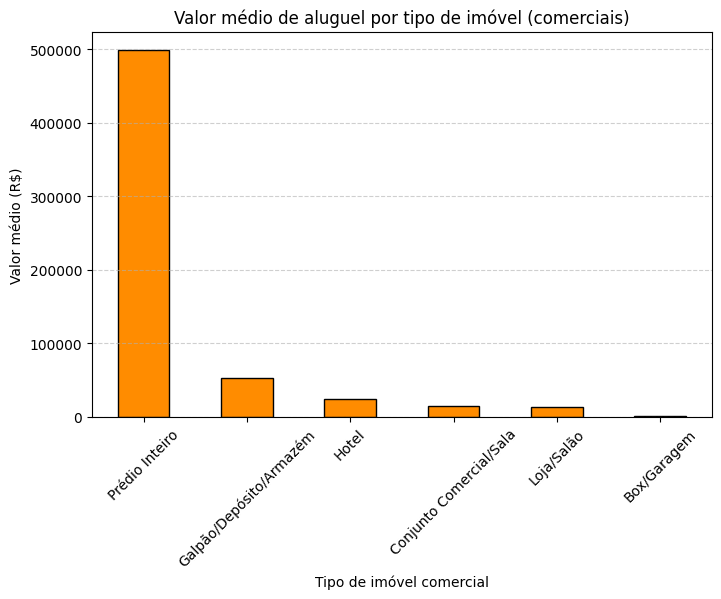

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
media_tipo_comerc.plot(kind='bar', edgecolor='black', color='darkorange')
plt.title('Valor médio de aluguel por tipo de imóvel (comerciais)')
plt.ylabel('Valor médio (R$)')
plt.xlabel('Tipo de imóvel comercial')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


## Qual o percentual de cada tipo de imóvel na nossa base de dados?

In [103]:
# Calcula o percentual de cada tipo de imóvel
percentual_tipo = (
    df['tipo']
      .value_counts(normalize=True) * 100
).round(2)

# Exibe os resultados em ordem decrescente
print(percentual_tipo)

# Converte para DataFrame (útil se quiser exportar ou plotar)
percentual_tipo_df = percentual_tipo.reset_index()
percentual_tipo_df.columns = ['Tipo de imóvel', 'Percentual (%)']
percentual_tipo_df


tipo
Apartamento                    59.26
Conjunto Comercial/Sala        20.68
Loja/Salão                      4.33
Casa de Condomínio              3.02
Casa                            2.93
Quitinete                       2.54
Galpão/Depósito/Armazém         1.89
Flat                            1.44
Prédio Inteiro                  0.91
Casa Comercial                  0.80
Casa de Vila                    0.76
Loja Shopping/ Ct Comercial     0.75
Box/Garagem                     0.25
Terreno Padrão                  0.21
Loft                            0.15
Sítio                           0.03
Loteamento/Condomínio           0.02
Studio                          0.01
Hotel                           0.01
Chácara                         0.00
Pousada/Chalé                   0.00
Indústria                       0.00
Name: proportion, dtype: float64


,Tipo de imóvel,Percentual (%)
0,Apartamento,59.26
1,Conjunto Comercial/Sala,20.68
2,Loja/Salão,4.33
3,Casa de Condomínio,3.02
4,Casa,2.93
5,Quitinete,2.54
6,Galpão/Depósito/Armazém,1.89
7,Flat,1.44
8,Prédio Inteiro,0.91
9,Casa Comercial,0.80


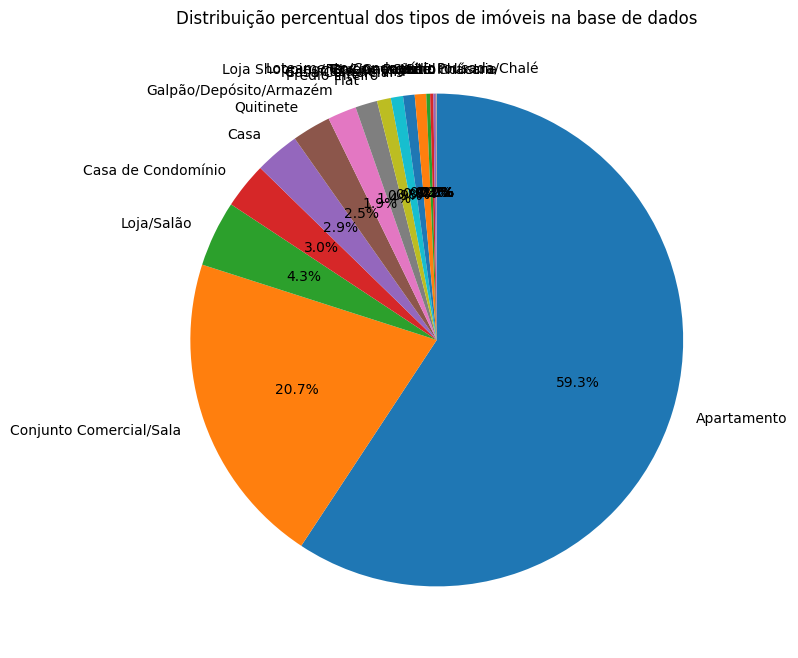

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.pie(
    percentual_tipo,
    labels=percentual_tipo.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('Distribuição percentual dos tipos de imóveis na base de dados')
plt.show()


categoria
Residencial    71.94
Comercial      28.06
Name: proportion, dtype: float64


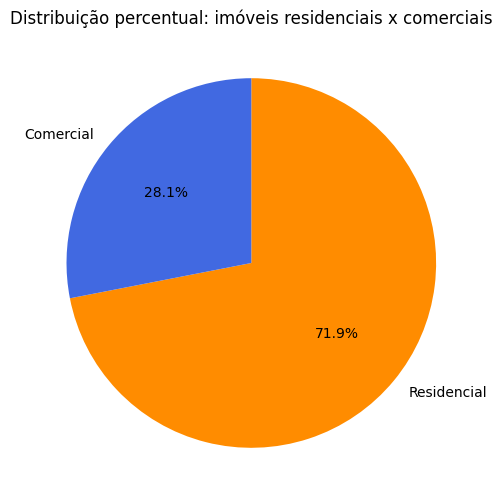

In [105]:
# Define listas
comerciais = [
    'conjunto comercial/sala', 'loja/salão', 'ponto comercial',
    'galpão/depósito/armazém', 'prédio inteiro', 'box/garagem',
    'hotel', 'kiosk', 'andar', 'terreno comercial'
]

# Normaliza a coluna 'tipo'
tipos_norm = df['tipo'].astype(str).str.strip().str.lower()

# Cria uma nova coluna classificando cada imóvel
df['categoria'] = np.where(
    tipos_norm.isin([t.lower() for t in comerciais]),
    'Comercial',
    'Residencial'
)

# Calcula o percentual de cada categoria
percentual_categoria = (
    df['categoria'].value_counts(normalize=True) * 100
).round(2)

print(percentual_categoria)

# Visualização
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(
    percentual_categoria,
    labels=percentual_categoria.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['darkorange', 'royalblue'],
    counterclock=False
)
plt.title('Distribuição percentual: imóveis residenciais x comerciais')
plt.show()


## 🏢 Selecionando apenas os imóveis do tipo Apartamento

Para realizar análises específicas, foi criado um subconjunto da base contendo apenas registros cujo tipo é “Apartamento”.  
Esse filtro permite estudar características específicas desse tipo de imóvel, como valor médio de aluguel, área média, número de quartos e outros atributos.


In [106]:
# Cria uma cópia apenas com imóveis do tipo apartamento
df_apto = df[df['tipo'].str.strip().str.lower() == 'apartamento'].copy()

# Exibe um resumo
print("Total de imóveis:", len(df))
print("Total de apartamentos:", len(df_apto))
print("Proporção de apartamentos: {:.2f}%".format((len(df_apto)/len(df))*100))

# Visualiza as primeiras linhas
df_apto.head()


Total de imóveis: 32960
Total de apartamentos: 19532
Proporção de apartamentos: 59.26%


,tipo,bairro,quartos,vagas,suites,area,valor,condominio,iptu,categoria
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,Residencial
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN,Residencial
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN,Residencial
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0,Residencial
10,Apartamento,Centro,1,0,0,36,1200.0,NaN,NaN,Residencial


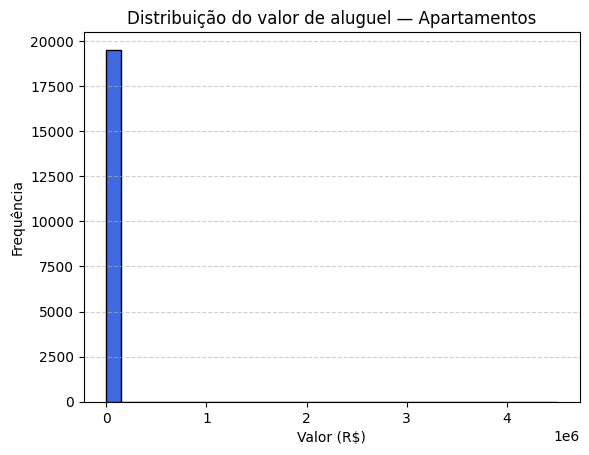

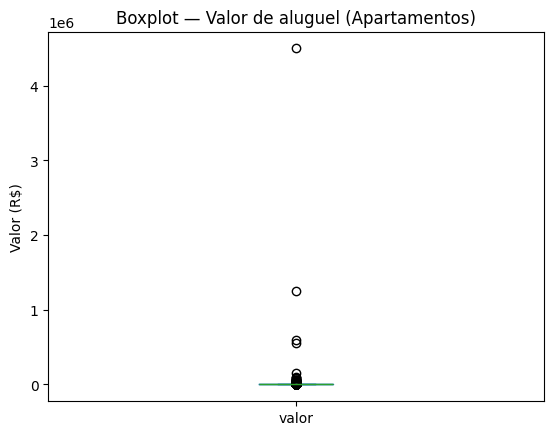

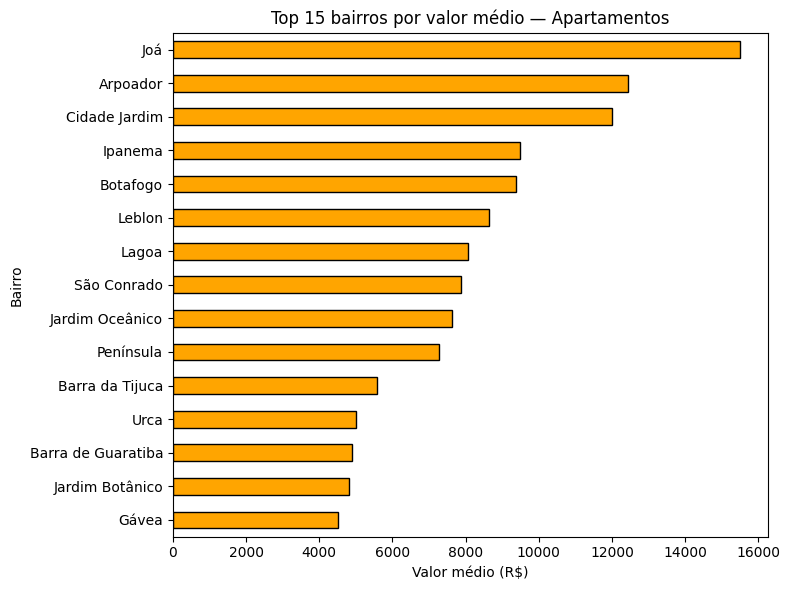

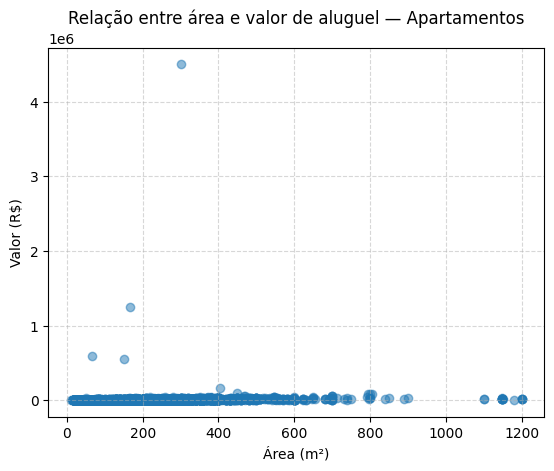

In [113]:
import matplotlib.pyplot as plt

# 🔹 1. Histograma do valor de aluguel
plt.figure()
df_apto['valor'].dropna().plot(kind='hist', bins=30, color='royalblue', edgecolor='black')
plt.title('Distribuição do valor de aluguel — Apartamentos')
plt.xlabel('Valor (R$)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 🔹 2. Boxplot do valor (para ver outliers)
plt.figure()
df_apto['valor'].dropna().plot(kind='box', vert=True)
plt.title('Boxplot — Valor de aluguel (Apartamentos)')
plt.ylabel('Valor (R$)')
plt.show()

# 🔹 3. Top 15 bairros mais caros (média de aluguel)
top_bairros = (
    df_apto.groupby('bairro')['valor']
           .mean()
           .sort_values(ascending=False)
           .head(15)
)

plt.figure(figsize=(8,6))
top_bairros[::-1].plot(kind='barh', color='orange', edgecolor='black')
plt.title('Top 15 bairros por valor médio — Apartamentos')
plt.xlabel('Valor médio (R$)')
plt.ylabel('Bairro')
plt.tight_layout()
plt.show()
#- O **gráfico de dispersão (Área × Valor)** ajuda a visualizar como o tamanho do imóvel impacta o preço.
# 🔹 4. Dispersão: Área x Valor
plt.figure()
plt.scatter(df_apto['area'], df_apto['valor'], alpha=0.5)
plt.title('Relação entre área e valor de aluguel — Apartamentos')
plt.xlabel('Área (m²)')
plt.ylabel('Valor (R$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 🏢 Análise dos apartamentos

Os gráficos mostram a distribuição e o comportamento dos valores de aluguel para apartamentos:

- O **histograma** revela a faixa de preços mais comum e possíveis concentrações em valores baixos ou altos.  
- O **boxplot** evidencia outliers (imóveis muito caros).  
- O **ranking dos bairros** mostra as regiões com aluguel médio mais elevado.  
- O **gráfico de dispersão (Área × Valor)** ajuda a visualizar como o tamanho do imóvel impacta o preço.


### **Selecionando apenas os imóveis do tipo apartamento**

In [114]:
# Criar um novo DataFrame somente com apartamentos
df_apto = df[df['tipo'].str.strip().str.lower() == 'apartamento'].copy()

# Exibe um resumo do filtro
print("Total de imóveis na base:", len(df))
print("Total de apartamentos:", len(df_apto))
print("Proporção de apartamentos: {:.2f}%".format((len(df_apto)/len(df))*100))

# Visualiza as primeiras linhas
df_apto.head()


Total de imóveis na base: 32960
Total de apartamentos: 19532
Proporção de apartamentos: 59.26%


,tipo,bairro,quartos,vagas,suites,area,valor,condominio,iptu,categoria
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,Residencial
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN,Residencial
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN,Residencial
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0,Residencial
10,Apartamento,Centro,1,0,0,36,1200.0,NaN,NaN,Residencial


In [115]:
df['tipo'].value_counts()


tipo
Apartamento                    19532
Conjunto Comercial/Sala         6815
Loja/Salão                      1426
Casa de Condomínio               996
Casa                             967
Quitinete                        836
Galpão/Depósito/Armazém          623
Flat                             476
Prédio Inteiro                   301
Casa Comercial                   265
Casa de Vila                     249
Loja Shopping/ Ct Comercial      247
Box/Garagem                       82
Terreno Padrão                    70
Loft                              51
Sítio                             10
Loteamento/Condomínio              5
Studio                             4
Hotel                              2
Chácara                            1
Pousada/Chalé                      1
Indústria                          1
Name: count, dtype: int64

In [116]:
df_apto = df[df['tipo'].str.lower().str.contains('apart', na=False)].copy()


## 🏢 Selecionando apenas os imóveis do tipo Apartamento

Para realizar análises específicas, foi criado um subconjunto da base contendo apenas registros de imóveis classificados como “Apartamento”.  
Esse filtro permite compreender o comportamento de aluguel desse tipo de imóvel, como média de preço, área média e distribuição geográfica.


In [120]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [121]:
# ✅ Garantir tipos numéricos
for c in ['quartos','vagas','suites','area','valor','condominio','iptu']:
    if c in df_apto.columns:
        df_apto[c] = pd.to_numeric(df_apto[c], errors='coerce')

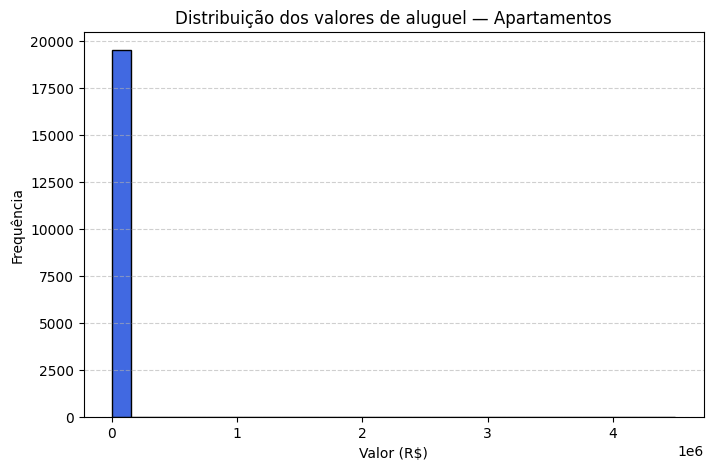

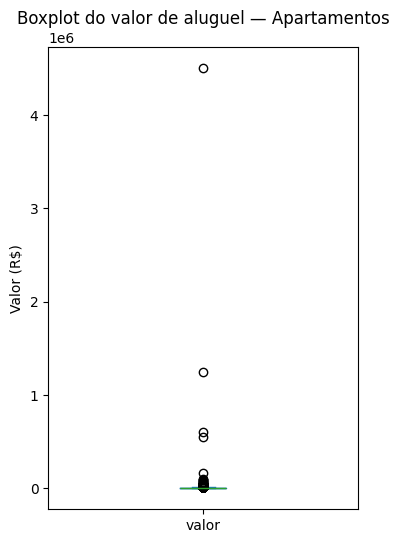

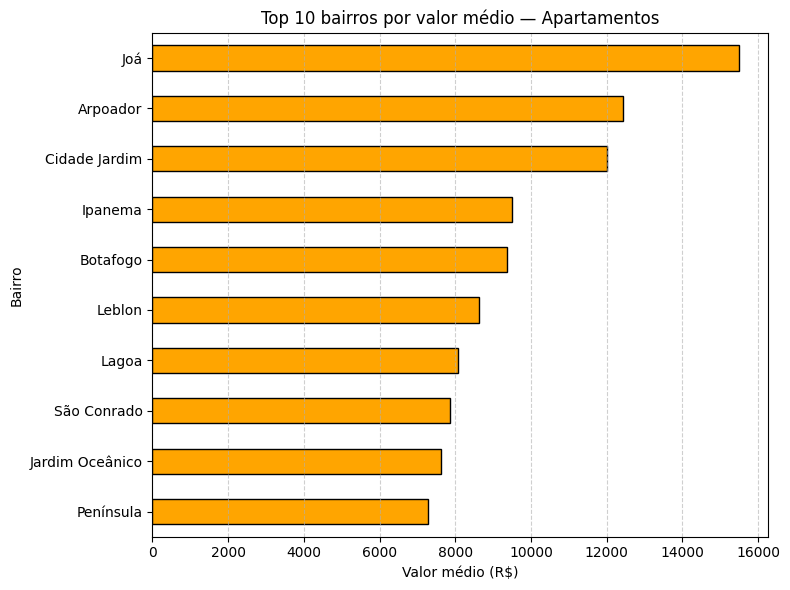

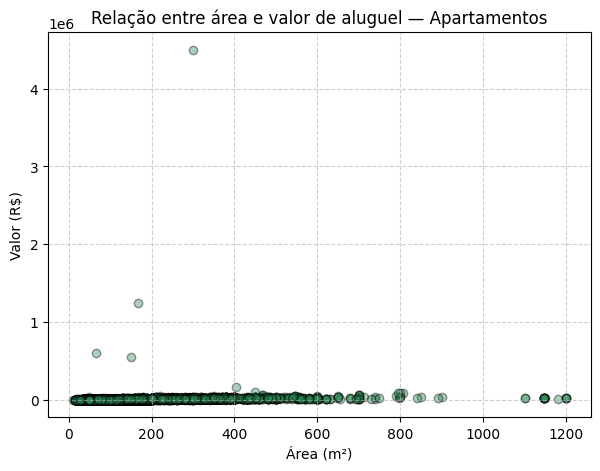

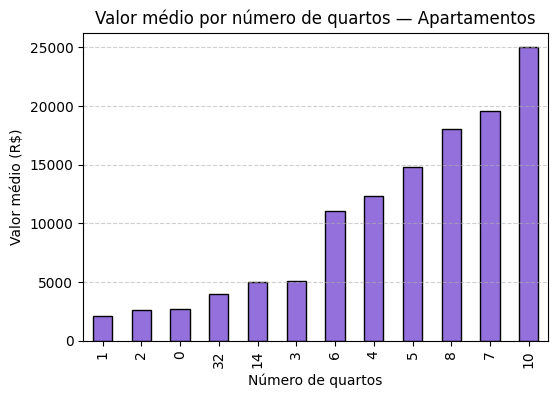

In [122]:
# 🔹 1. Histograma — Distribuição dos valores de aluguel
plt.figure(figsize=(8,5))
df_apto['valor'].dropna().plot(kind='hist', bins=30, color='royalblue', edgecolor='black')
plt.title('Distribuição dos valores de aluguel — Apartamentos')
plt.xlabel('Valor (R$)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 🔹 2. Boxplot — Faixa de preços e outliers
plt.figure(figsize=(4,6))
df_apto['valor'].dropna().plot(kind='box')
plt.title('Boxplot do valor de aluguel — Apartamentos')
plt.ylabel('Valor (R$)')
plt.show()

# 🔹 3. Top 10 bairros com maior valor médio
top_bairros = (
    df_apto.groupby('bairro')['valor']
           .mean()
           .sort_values(ascending=False)
           .head(10)
)

plt.figure(figsize=(8,6))
top_bairros[::-1].plot(kind='barh', color='orange', edgecolor='black')
plt.title('Top 10 bairros por valor médio — Apartamentos')
plt.xlabel('Valor médio (R$)')
plt.ylabel('Bairro')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 🔹 4. Dispersão — Relação entre área e valor
plt.figure(figsize=(7,5))
plt.scatter(df_apto['area'], df_apto['valor'], alpha=0.4, color='seagreen', edgecolor='k')
plt.title('Relação entre área e valor de aluguel — Apartamentos')
plt.xlabel('Área (m²)')
plt.ylabel('Valor (R$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 🔹 5. Valor médio por número de quartos
media_quartos = (
    df_apto.groupby('quartos')['valor']
           .mean()
           .sort_values(ascending=True)
)

plt.figure(figsize=(6,4))
media_quartos.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Valor médio por número de quartos — Apartamentos')
plt.xlabel('Número de quartos')
plt.ylabel('Valor médio (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## 🏢 Análise dos apartamentos

Nesta seção, analisamos exclusivamente os imóveis do tipo **Apartamento**, o grupo mais representativo da base.

- O **histograma** mostra a concentração dos valores de aluguel.
- O **boxplot** destaca a faixa de preços e eventuais outliers.
- O **ranking dos bairros** evidencia as regiões mais caras.
- O **gráfico de dispersão (Área × Valor)** revela como o tamanho influencia o preço.
- O **gráfico por número de quartos** mostra o aumento do valor médio conforme o imóvel se torna mais espaçoso.


# Tratando e filtrando os dados

## Lidando com dados nulos

In [123]:
# 1️⃣ Carrega a base com separador correto
df = pd.read_csv("datasets/aluguel.csv", sep=";", encoding="utf-8")
df.columns = df.columns.str.strip().str.lower()

# 2️⃣ Converte colunas numéricas
colunas_numericas = ['quartos', 'vagas', 'suites', 'area', 'valor', 'condominio', 'iptu']
for col in colunas_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3️⃣ Verifica dados nulos
print("Valores ausentes por coluna:\n")
print(df.isna().sum())
print("\nPercentual de valores nulos (%):\n")
print(round((df.isna().sum() / len(df)) * 100, 2))

Valores ausentes por coluna:

tipo              0
bairro            0
quartos           0
vagas             0
suites            0
area              0
valor            17
condominio     4093
iptu          10237
dtype: int64

Percentual de valores nulos (%):

tipo           0.00
bairro         0.00
quartos        0.00
vagas          0.00
suites         0.00
area           0.00
valor          0.05
condominio    12.42
iptu          31.06
dtype: float64


In [124]:
# 🔹 Substituir nulos de custos (condomínio, IPTU) por 0
df['condominio'] = df['condominio'].fillna(0)
df['iptu'] = df['iptu'].fillna(0)

# 🔹 Remover registros com valor de aluguel ausente
df = df.dropna(subset=['valor'])

# 🔹 Para colunas categóricas (bairro, tipo), preencher com "Não informado"
df['bairro'] = df['bairro'].fillna('Não informado')
df['tipo'] = df['tipo'].fillna('Não informado')


In [125]:
print("Valores ausentes restantes:\n")
print(df.isna().sum())


Valores ausentes restantes:

tipo          0
bairro        0
quartos       0
vagas         0
suites        0
area          0
valor         0
condominio    0
iptu          0
dtype: int64


## 🧹 Tratando e filtrando os dados — Lidando com dados nulos

Durante o tratamento, foi identificado que algumas variáveis apresentavam valores ausentes.  
Para evitar distorções nas análises, adotamos as seguintes estratégias:

- **Condomínio e IPTU:** substituídos por 0, pois a ausência representa casos sem cobrança.  
- **Valor de aluguel:** registros sem esse valor foram removidos.  
- **Bairro e Tipo:** valores ausentes substituídos por “Não informado”.  

Esses tratamentos garantem que as análises estatísticas e visuais sejam consistentes e sem interferências causadas por dados incompletos.


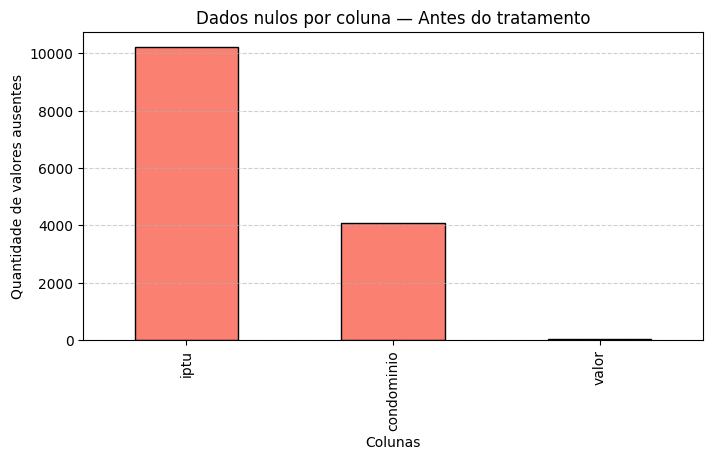

In [128]:
# 1️⃣ Carregar o dataset com separador correto
df = pd.read_csv("datasets/aluguel.csv", sep=";", encoding="utf-8")
df.columns = df.columns.str.strip().str.lower()

# 2️⃣ Converter colunas numéricas
colunas_numericas = ['quartos','vagas','suites','area','valor','condominio','iptu']
for col in colunas_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3️⃣ Contagem de nulos antes do tratamento
nulos_antes = df.isna().sum()

# Visualização dos nulos antes
plt.figure(figsize=(8,4))
nulos_antes[nulos_antes > 0].sort_values(ascending=False).plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Dados nulos por coluna — Antes do tratamento')
plt.ylabel('Quantidade de valores ausentes')
plt.xlabel('Colunas')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [129]:
# 4️⃣ Tratamento dos nulos
df['condominio'] = df['condominio'].fillna(0)
df['iptu'] = df['iptu'].fillna(0)
df = df.dropna(subset=['valor'])
df['bairro'] = df['bairro'].fillna('Não informado')
df['tipo'] = df['tipo'].fillna('Não informado')

# 5️⃣ Contagem de nulos após o tratamento
nulos_depois = df.isna().sum()

In [132]:
# 6️⃣ Exibir resumo comparativo
comparativo = pd.DataFrame({
    'Antes': nulos_antes,
    'Depois': nulos_depois
})
print(comparativo)

            Antes  Depois
tipo            0       0
bairro          0       0
quartos         0       0
vagas           0       0
suites          0       0
area            0       0
valor          17       0
condominio   4093       0
iptu        10237       0


## Removendo registros

In [134]:
# ✅ Verificar novamente o tamanho inicial da base
print(f"Tamanho original da base: {len(df)} registros\n")

Tamanho original da base: 32943 registros



In [135]:
# 1️⃣ Removendo duplicados
duplicados = df.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")

Registros duplicados encontrados: 1160


In [136]:
# Remove duplicatas e reseta o índice
df = df.drop_duplicates().reset_index(drop=True)
print(f"Base após remoção de duplicados: {len(df)} registros\n")

Base após remoção de duplicados: 31783 registros



In [137]:
# 2️⃣ Removendo registros com valores nulos críticos (ex.: sem valor de aluguel)
# Já tratamos antes, mas aqui garantimos novamente
df = df.dropna(subset=['valor'])

In [140]:
# 3️⃣ Removendo registros com área inválida (área = 0 ou negativa)
df = df[df['area'] > 0]

In [141]:
# 4️⃣ Removendo registros com valor de aluguel igual a zero
df = df[df['valor'] > 0]

In [142]:
# 5️⃣ (Opcional) Remover bairros não informados, se necessário
df = df[df['bairro'].str.lower() != 'não informado']

In [143]:
# ✅ Resumo final
print("Base final após remoções:")
print(f"Total de registros: {len(df)}")
print(f"Colunas: {df.shape[1]}")

Base final após remoções:
Total de registros: 31726
Colunas: 9


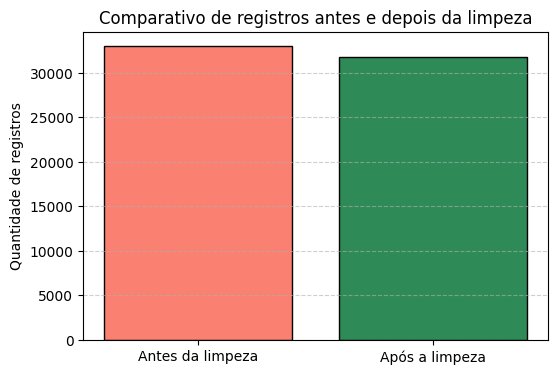

In [144]:
# Crie um gráfico de barras mostrando a diferença antes/depois das remoções
import matplotlib.pyplot as plt

valores = [32960, len(df)]  # substitua 32960 pelo número inicial real
labels = ['Antes da limpeza', 'Após a limpeza']

plt.figure(figsize=(6,4))
plt.bar(labels, valores, color=['salmon', 'seagreen'], edgecolor='black')
plt.title('Comparativo de registros antes e depois da limpeza')
plt.ylabel('Quantidade de registros')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


## 🧽 Removendo registros

Após o tratamento dos dados nulos, realizamos a remoção de registros que poderiam comprometer a qualidade das análises:

- **Duplicados:** eliminados para evitar contagem repetida.  
- **Registros sem valor ou área:** excluídos, pois inviabilizam análises financeiras.  
- **Valores iguais a zero:** removidos, pois indicam ausência de informação válida.  
- **Bairros não informados:** descartados para garantir consistência geográfica.

Essa etapa resultou em uma base mais limpa, confiável e pronta para as análises exploratórias e comparativas.


## Filtros

### **1. Apartamentos que possuem `1 quarto` e `aluguel menor que 1200`**



In [145]:
# (Se ainda não garantiu) converter para numérico
for c in ['quartos','valor']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

In [146]:
# Filtro 1: apartamentos, 1 quarto, aluguel < 1200
mask = (
    df['tipo'].str.strip().str.lower().eq('apartamento') &
    (df['quartos'] == 1) &
    (df['valor'] < 1200)
)

df_filtro1 = df[mask].copy()

In [147]:
# Resumo rápido
total_base = len(df)
total_apto = (df['tipo'].str.lower() == 'apartamento').sum()
print(f"Registros no filtro: {len(df_filtro1)}")
print(f"% do total da base: {len(df_filtro1)/total_base*100:.2f}%")
print(f"% dentre apartamentos: {len(df_filtro1)/total_apto*100:.2f}%")

Registros no filtro: 605
% do total da base: 1.91%
% dentre apartamentos: 3.21%


In [148]:
# Amostra para conferir
df_filtro1.head()

,tipo,bairro,quartos,vagas,suites,area,valor,condominio,iptu
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0
28,Apartamento,Tijuca,1,0,0,48,750.0,772.0,25.0
54,Apartamento,Centro,1,0,0,27,750.0,371.0,19.0
93,Apartamento,Centro,1,1,0,37,1100.0,540.0,900.0


In [149]:
df_filtro1['bairro'].value_counts().head(10)


bairro
Centro                     84
Tijuca                     30
Méier                      25
Copacabana                 23
Campo Grande               22
Vila Isabel                21
Freguesia (Jacarepaguá)    17
Vila da Penha              17
Glória                     14
Engenho Novo               14
Name: count, dtype: int64

In [151]:
df_filtro1.to_csv("datasets/apartamentos_1q_menor1200.csv", index=False, encoding="utf-8")


### **2. `Apartamentos` que possuem pelo menos `2 quartos`, `aluguel menor que 3000` e `area maior que 70`**

In [152]:
# (garantia) converter colunas usadas para numérico
for c in ['quartos','valor','area']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

mask2 = (
    df['tipo'].str.strip().str.lower().eq('apartamento') &
    (df['quartos'] >= 2) &
    (df['valor']   < 3000) &
    (df['area']    > 70)
)

df_filtro2 = df[mask2].copy()

In [153]:
# Resumo rápido
tot_base = len(df)
tot_apto = (df['tipo'].str.lower() == 'apartamento').sum()
print(f"Registros no filtro 2: {len(df_filtro2)}")
print(f"% do total da base: {len(df_filtro2)/tot_base*100:.2f}%")
print(f"% dentre apartamentos: {len(df_filtro2)/tot_apto*100:.2f}%")

# Amostra
df_filtro2.head()

Registros no filtro 2: 4446
% do total da base: 14.01%
% dentre apartamentos: 23.59%


,tipo,bairro,quartos,vagas,suites,area,valor,condominio,iptu
12,Apartamento,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0
21,Apartamento,Tijuca,2,1,0,110,1900.0,700.0,138.0
24,Apartamento,Tijuca,2,1,0,78,2000.0,700.0,0.0
32,Apartamento,Botafogo,2,1,0,76,2500.0,740.0,0.0
36,Apartamento,Recreio dos Bandeirantes,3,1,1,105,2300.0,648.0,0.0


## Salvando os dados

In [155]:
import os

In [156]:
# Garante que exista uma pasta para salvar os arquivos
os.makedirs("datasets/resultados", exist_ok=True)

# 🔹 1. Salvar a base principal tratada
df.to_csv("datasets/resultados/aluguel_tratado.csv", index=False, encoding="utf-8")

# 🔹 2. Salvar subconjuntos específicos
df_resid.to_csv("datasets/resultados/imoveis_residenciais.csv", index=False, encoding="utf-8")
df_comerc.to_csv("datasets/resultados/imoveis_comerciais.csv", index=False, encoding="utf-8")
df_apto.to_csv("datasets/resultados/apartamentos.csv", index=False, encoding="utf-8")

# 🔹 3. Salvar filtros de análise
df_filtro1.to_csv("datasets/resultados/apartamentos_1q_menor1200.csv", index=False, encoding="utf-8")
df_filtro2.to_csv("datasets/resultados/apartamentos_2q_area70_valor3000.csv", index=False, encoding="utf-8")

print("✅ Arquivos salvos com sucesso na pasta datasets/resultados/")

✅ Arquivos salvos com sucesso na pasta datasets/resultados/


## 💾 Salvando os dados

Após o tratamento e filtragem, os dados foram exportados em arquivos CSV separados para facilitar futuras análises:

- **aluguel_tratado.csv** – base completa limpa e padronizada;  
- **imoveis_residenciais.csv** e **imoveis_comerciais.csv** – bases divididas por categoria;  
- **apartamentos.csv** – somente registros do tipo apartamento;  
- **apartamentos_1q_menor1200.csv** e **apartamentos_2q_area70_valor3000.csv** – filtros específicos de estudo.

Esses arquivos garantem reprodutibilidade e permitem que novas análises sejam feitas sem necessidade de repetir todo o tratamento.


# Manipulando os dados

## Criando colunas numéricas

In [157]:
# 👀 Defina aqui as colunas que devem ser numéricas
colunas_numericas = ['quartos','vagas','suites','area','valor','condominio','iptu']

def para_numero_robusto(s: pd.Series) -> pd.Series:
    """
    Converte strings para float de forma robusta:
    - remove símbolos (R$, espaços, etc.)
    - remove separador de milhar (.)
    - troca vírgula decimal por ponto
    - coage erros para NaN
    """
    s = s.astype(str)
    s = s.str.replace(r'[^0-9,.\-]', '', regex=True)  # mantém dígitos, sinais, . e ,
    s = s.str.replace('.', '', regex=False)           # remove milhar
    s = s.str.replace(',', '.', regex=False)          # vírgula -> ponto
    return pd.to_numeric(s, errors='coerce')


In [158]:
# 🔧 Converte cada coluna listada (se existir no df)
antes = df.dtypes.copy()
for c in colunas_numericas:
    if c in df.columns:
        df[c] = para_numero_robusto(df[c])

depois = df.dtypes

print("Tipos antes:\n", antes[colunas_numericas][antes.index.intersection(colunas_numericas)])
print("\nTipos depois:\n", depois[colunas_numericas][depois.index.intersection(colunas_numericas)])

Tipos antes:
 quartos         int64
vagas           int64
suites          int64
area            int64
valor         float64
condominio    float64
iptu          float64
dtype: object

Tipos depois:
 quartos       int64
vagas         int64
suites        int64
area          int64
valor         int64
condominio    int64
iptu          int64
dtype: object


In [159]:
# ✅ Regras opcionais de qualidade (ajuste conforme seu caso)
# Remove valores impossíveis
if 'area' in df.columns:
    df.loc[df['area'] <= 0, 'area'] = np.nan
if 'valor' in df.columns:
    df.loc[df['valor'] <= 0, 'valor'] = np.nan

In [160]:
# ✨ Novas colunas derivadas úteis
if set(['valor','condominio','iptu']).issubset(df.columns):
    df['valor_total'] = df[['valor','condominio','iptu']].sum(axis=1, min_count=1)  # soma respeitando NaN
if set(['valor_total','area']).issubset(df.columns):
    df['preco_m2'] = df['valor_total'] / df['area']

In [161]:
# 📌 Resumo rápido (mostra quantos números válidos temos em cada coluna)
resumo_num = df[colunas_numericas + [c for c in ['valor_total','preco_m2'] if c in df.columns]] \
               .agg(['count','mean','min','max']).T
print("\nResumo numérico:\n", resumo_num.round(2))


Resumo numérico:
                count       mean     min           max
quartos      31726.0       1.77    0.00  1.000000e+02
vagas        31726.0       1.77    0.00  1.966000e+03
suites       31726.0       0.66    0.00  7.000000e+01
area         31726.0     231.71    1.00  9.000000e+04
valor        31726.0  131464.65  750.00  1.200000e+09
condominio   31726.0   20999.96    0.00  6.552570e+07
iptu         31726.0   16684.04    0.00  2.705307e+08
valor_total  31726.0  169148.65  750.00  1.200100e+09
preco_m2     31726.0     676.06    0.21  1.000083e+06


## Criando colunas categóricas

In [162]:
from pandas.api.types import CategoricalDtype

In [165]:
# 1) Categoria Residencial/Comercial (ajuste a lista conforme sua base)
comerciais = [
    'conjunto comercial/sala', 'loja/salão', 'ponto comercial',
    'galpão/depósito/armazém', 'prédio inteiro', 'box/garagem',
    'hotel', 'andar', 'loteamento/condomínio', 'indústria'
]